In [1]:
import numpy as np
import sep
import astropy.io.fits as astropyio
import matplotlib.pyplot as plt
from matplotlib import rcParams

In [2]:
rcParams['figure.figsize'] = [10., 8.]

# First we must read the data and show the image

In [3]:
# read image into standard 2-d numpy array
data = astropyio.getdata('finaldata.fits')

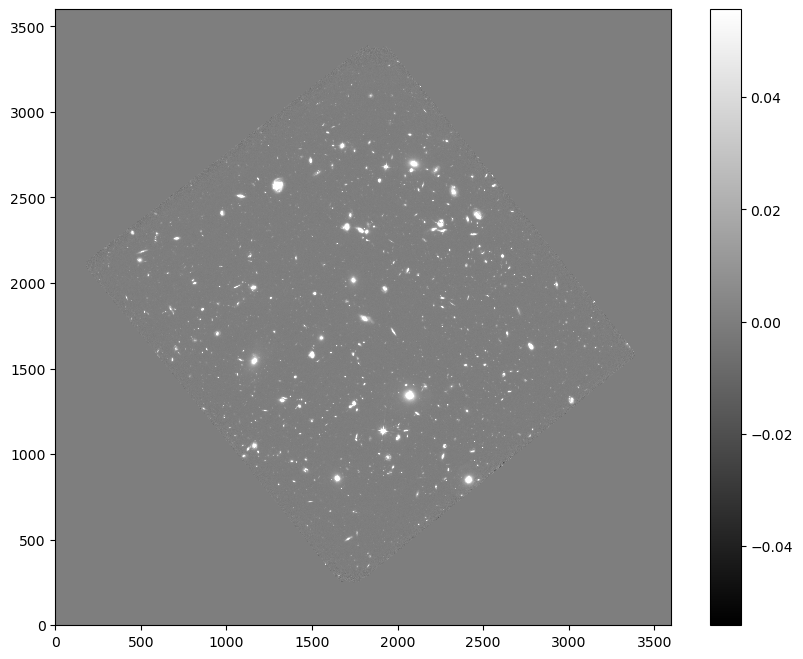

In [4]:
# show the image
m, s = np.mean(data), np.std(data)
plt.imshow(data, interpolation='nearest', cmap='gray', vmin=m-s, vmax=m+s, origin='lower')
plt.colorbar();

In [5]:
# measure a spatially varying background on the image
data = data.astype(data.dtype.newbyteorder('='))
bkg = sep.Background(data)

In [6]:
# get a "global" mean and noise of the image background:
print(bkg.globalback)
print(bkg.globalrms)

0.0
0.0005398219218477607


In [7]:
# evaluate background as 2-d array, same size as original image
bkg_image = bkg.back()
# bkg_image = np.array(bkg) # equivalent to above

# Then we must process the image in order to prepare it for analysis

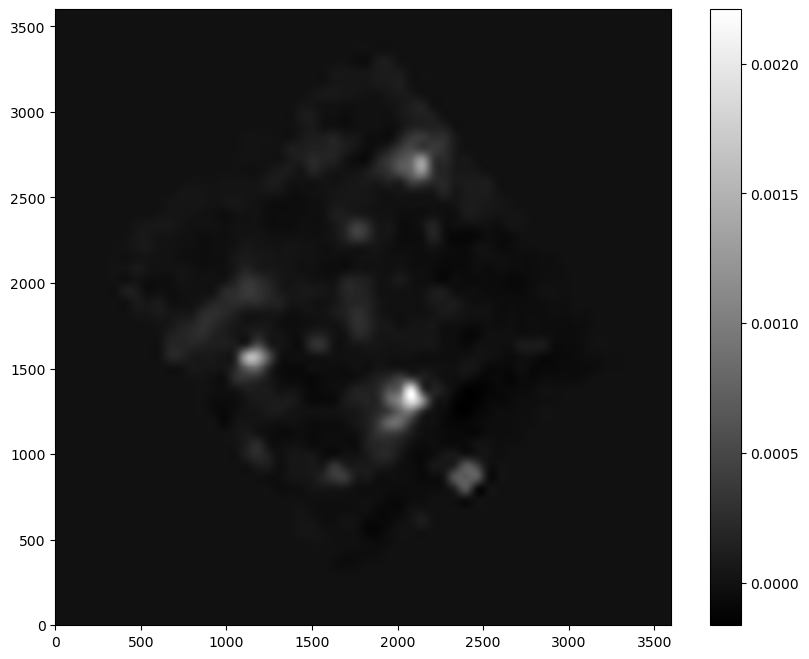

In [8]:
# show the background
plt.imshow(bkg_image, interpolation='nearest', cmap='gray', origin='lower')
plt.colorbar();

In [9]:
# evaluate the background noise as 2-d array, same size as original image
bkg_rms = bkg.rms()

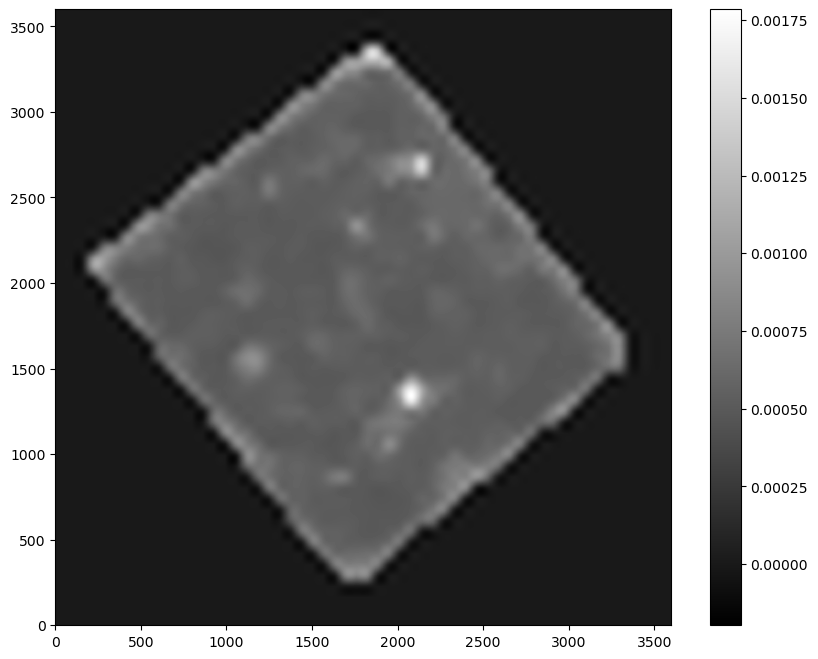

In [10]:
# show the background noise
plt.imshow(bkg_rms, interpolation='nearest', cmap='gray', origin='lower')
plt.colorbar();

In [11]:
# subtract the background
data_sub = data - bkg

In [12]:
objects = sep.extract(data_sub, 20, err=bkg.globalrms)

# When we do analyze it, we find that there are 939 objects that are bright enough to be considered significant

In [13]:
# how many objects were detected
len(objects)

939

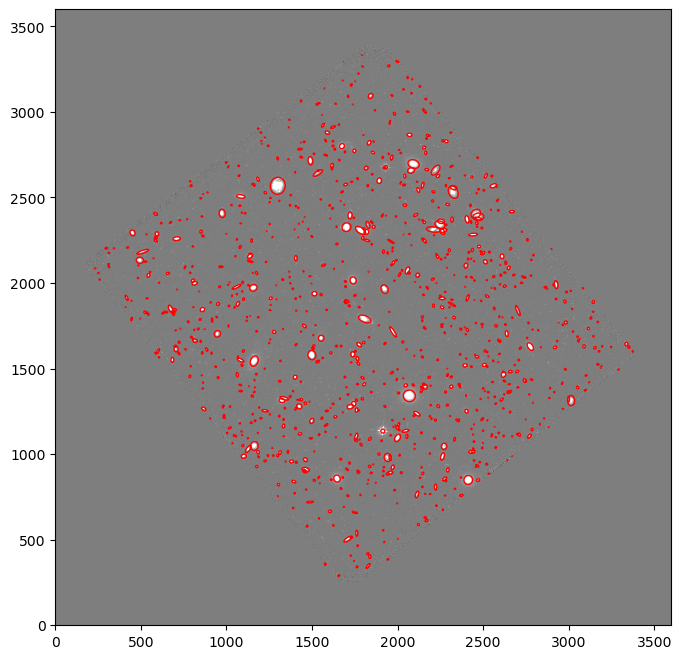

In [14]:
from matplotlib.patches import Ellipse

# plot background-subtracted image
fig, ax = plt.subplots()
m, s = np.mean(data_sub), np.std(data_sub)
im = ax.imshow(data_sub, interpolation='nearest', cmap='gray',
               vmin=m-s, vmax=m+s, origin='lower')

# plot an ellipse for each object
for i in range(len(objects)):
    e = Ellipse(xy=(objects['x'][i], objects['y'][i]),
                width=6*objects['a'][i],
                height=6*objects['b'][i],
                angle=objects['theta'][i] * 180. / np.pi)
    e.set_facecolor('none')
    e.set_edgecolor('red')
    ax.add_artist(e)

In [15]:
# available fields simply for reference
objects.dtype.names

('thresh',
 'npix',
 'tnpix',
 'xmin',
 'xmax',
 'ymin',
 'ymax',
 'x',
 'y',
 'x2',
 'y2',
 'xy',
 'errx2',
 'erry2',
 'errxy',
 'a',
 'b',
 'theta',
 'cxx',
 'cyy',
 'cxy',
 'cflux',
 'flux',
 'cpeak',
 'peak',
 'xcpeak',
 'ycpeak',
 'xpeak',
 'ypeak',
 'flag')

In [16]:
flux, fluxerr, flag = sep.sum_circle(data_sub, objects['x'], objects['y'],
                                     3.0, err=bkg.globalrms, gain=1.0)

In [17]:
# show the first 10 objects results:
for i in range(10):
    print("object {:d}: flux = {:f} +/- {:f}".format(i, flux[i], fluxerr[i]))

object 0: flux = 1.148925 +/- 1.071883
object 1: flux = 0.551862 +/- 0.742880
object 2: flux = 1.119971 +/- 1.058291
object 3: flux = 0.885204 +/- 0.940857
object 4: flux = 0.288213 +/- 0.536863
object 5: flux = 0.688374 +/- 0.829688
object 6: flux = 0.498388 +/- 0.705972
object 7: flux = 0.755299 +/- 0.869084
object 8: flux = 1.255633 +/- 1.120554
object 9: flux = 0.971109 +/- 0.985453


# There are 939 sources in the data. Here is a histogram of their fluxes.

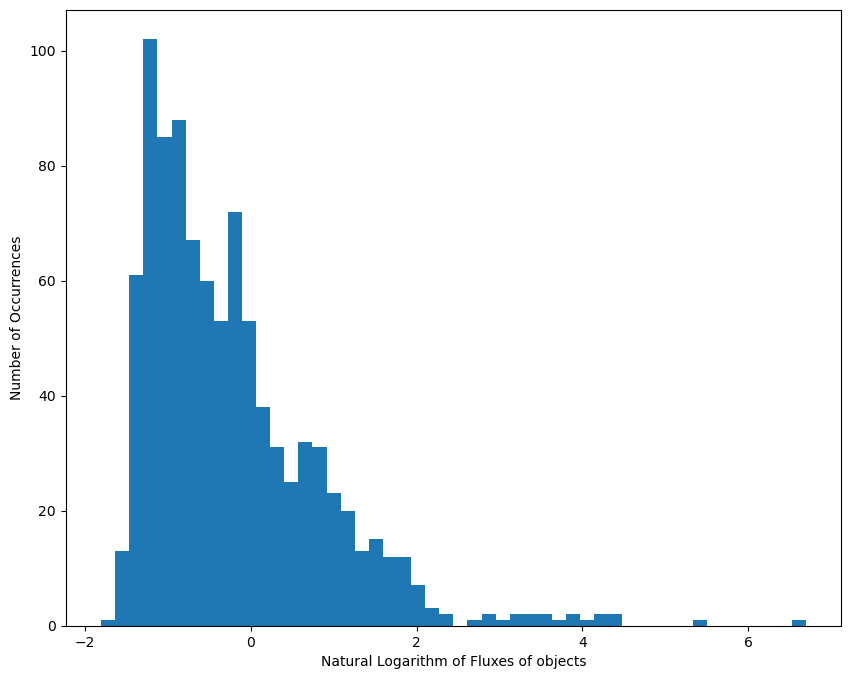

In [18]:
plt.hist(np.log(flux),bins=50)
plt.xlabel('Natural Logarithm of Fluxes of objects')
plt.ylabel('Number of Occurrences')
plt.show()

In [19]:
mean = np.mean(flux)
print('This is the mean:', mean)
std = np.std(flux)
median = np.median(flux)
print('This is the standard deviation:', std)
print('This is the median:', median)

This is the mean: 3.027042236089139
This is the standard deviation: 27.865219113239107
This is the median: 0.6342044152691961


# The mean of the fluxes is 3.027.
# The standard deviation of the fluxes is 27.87.
# The median of the fluxes is 0.6342.

In [20]:
print(max(objects['flux']))

1195.764892578125


# The largest outlier has a flux of 1195.

In [21]:
sigma_amount = max(objects['flux'])/std
print(sigma_amount)

42.91245253513914


# That outlier is  42.91-sigma event. Said another way, it is 42.91 standard deviations away from the mean.